In [15]:
import numpy as np
import pandas as pd
from pathlib import Path
import re
import matplotlib.pyplot as plt
from scipy.stats import weibull_min
import math
from windrose import WindroseAxes
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.dates as mdates


## 1 Dataset 1: Long-Term Wind Data (10-min Resolution)

In [19]:
dir1 = Path("C:/Users/HP/Desktop/wind_measurement/Exercise2/long_term_jena_10min.csv")
dataset1 = pd.read_csv(dir1,index_col=0, parse_dates=True)
print(dataset1.info())
print()
print("=" * 64)
print()
print(dataset1.isnull().sum())

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\HP\\Desktop\\wind_measurement\\Exercise2\\long_term_jena_10min.csv'

In [3]:
dataset1.head()

,wind_speed_mps,wind_direction_deg,temperature_degC
datetime,,,
2017-01-01 00:10:00,0.78,184.0,-4.91
2017-01-01 00:20:00,1.52,202.6,-5.05
2017-01-01 00:30:00,0.98,227.4,-4.98
2017-01-01 00:40:00,1.16,212.5,-4.88
2017-01-01 00:50:00,1.50,222.1,-5.17


### Dataset1: Step 1: Exploratory Data Analysis (Scales)

In [4]:
# Confriming the time range of the dataset
print("Start date:", dataset1.index.min())
print("End date:", dataset1.index.max())
print(f"Dataset contains {len(dataset1)} records in total")

# Selecting one year of data for analysis
dataset1_2024 = dataset1.loc['2024'].copy()
print("Start date of 2024 data:", dataset1_2024.index.min())
print("End date of 2024 data:", dataset1_2024.index.max())
print("Number of records in 2024 data:", len(dataset1_2024))

# Checking for missing timestamps in the 2024 data
full_year = pd.date_range(start=dataset1_2024.index.min(), end=dataset1_2024.index.max(), freq='10min')
len(full_year) == len(dataset1_2024)

Start date: 2017-01-01 00:10:00
End date: 2024-12-31 23:50:00
Dataset contains 420781 records in total
Start date of 2024 data: 2024-01-01 00:00:00
End date of 2024 data: 2024-12-31 23:50:00
Number of records in 2024 data: 52704


True

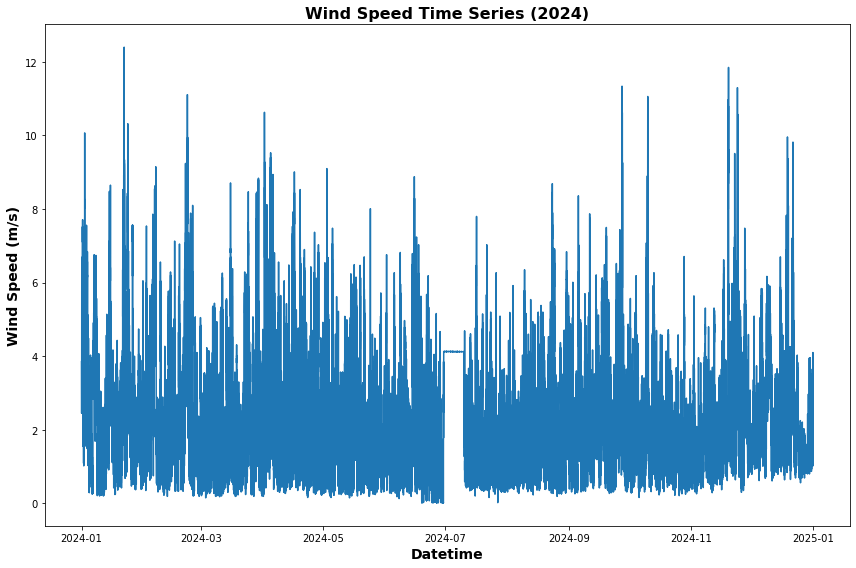

In [5]:
# Plotting the time series of the wind speed
plt.figure(figsize=(12,8))
plt.plot(dataset1_2024.index, dataset1_2024["wind_speed_mps"])
plt.title("Wind Speed Time Series (2024)", fontsize=16, fontweight="bold")
plt.xlabel("Datetime", fontsize=14, fontweight="bold")
plt.ylabel("Wind Speed (m/s)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [6]:
# Computing moving average and moving standard deviation of wind speed
window_size = 144  # 24 hours * 6 (10-minute intervals)
dataset1_2024["wind_speed_ma"] = dataset1_2024["wind_speed_mps"].rolling(window=window_size, center=True).mean()
dataset1_2024["wind_speed_mstd"] = dataset1_2024["wind_speed_mps"].rolling(window=window_size, center=True).std()
dataset1_2024["wind_speed_ma"]

datetime
2024-01-01 00:00:00   NaN
2024-01-01 00:10:00   NaN
2024-01-01 00:20:00   NaN
2024-01-01 00:30:00   NaN
2024-01-01 00:40:00   NaN
                       ..
2024-12-31 23:10:00   NaN
2024-12-31 23:20:00   NaN
2024-12-31 23:30:00   NaN
2024-12-31 23:40:00   NaN
2024-12-31 23:50:00   NaN
Name: wind_speed_ma, Length: 52704, dtype: float64

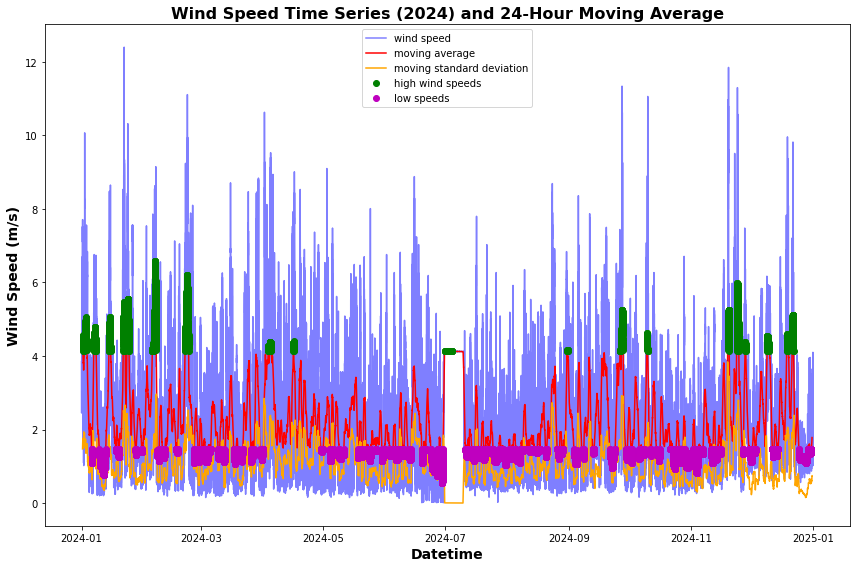

In [7]:
# Plotting the time series of the wind speed with moving average and standard deviation
# Plotting the time series of the wind speed
highs = dataset1_2024[dataset1_2024["wind_speed_ma"] > dataset1_2024["wind_speed_ma"].quantile(0.95)]
lows = dataset1_2024[dataset1_2024["wind_speed_ma"] < dataset1_2024["wind_speed_ma"].quantile(0.25)]
plt.figure(figsize=(12,8))
plt.plot(dataset1_2024.index, dataset1_2024["wind_speed_mps"], label="wind speed", color="blue", alpha=0.5)
plt.plot(dataset1_2024.index, dataset1_2024["wind_speed_ma"], label="moving average", color="red")
plt.plot(dataset1_2024.index, dataset1_2024["wind_speed_mstd"], label="moving standard deviation", color="orange")
plt.plot(highs.index, highs["wind_speed_ma"], "go", label="high wind speeds")
plt.plot(lows.index, lows["wind_speed_ma"], "mo", label="low speeds")
plt.title("Wind Speed Time Series (2024) and 24-Hour Moving Average", fontsize=16, fontweight="bold")
plt.xlabel("Datetime", fontsize=14, fontweight="bold")
plt.ylabel("Wind Speed (m/s)", fontsize=14, fontweight="bold")
plt.legend()
plt.tight_layout()
plt.show()

### Dataset1 Step2: Statiscal Discription

----
#### Weibull Distribution

The Weibull probability density function is given by:

$$f(u) = \frac{k}{A} \left( \frac{u}{A} \right)^{k-1} \exp \left[ -\left( \frac{u}{A} \right)^k \right]$$

where:

*   **$u$** is the wind speed
*   **$k$** is the shape factor
*   **$A$** is the scale factor

---

### Key Parameters:

*   **The scale factor ($A$):** Tells us the general windiness of the site. A larger $A$ means the site has higher typical wind speeds.
*   **The shape factor ($k$):** Tells us how broad or narrow the wind-speed distribution is. 
    -   A **low $k$** means the wind is highly variable and skewed, with many low speeds and occasional high speeds. 
    -  A **high $k$** means the wind speeds are more concentrated around the mean.



**Statistical Properties of the Weibull Distribution**

The **mean wind speed** is:
$$\bar{u} = A \Gamma \left( 1 + \frac{1}{k} \right)$$

The **variance** is:
$$\sigma^2 = A^2 \left[ \Gamma \left( 1 + \frac{2}{k} \right) - \Gamma^2 \left( 1 + \frac{1}{k} \right) \right]$$

The **expected cubic wind speed**, which is critical for power calculations, is:
$$E[u^3] = A^3 \Gamma \left( 1 + \frac{3}{k} \right)$$

---

**Note:** This last expression is especially important because wind power depends on $u^3$, rather than a simple linear relationship with $u$.

----

**Source**: [1] R. Gasch and J. Twele, "Wind Power Plants: Fundamentals, Design, Construction and Operation," 2nd ed. Springer, 2012.

K: 1.52, loc: 0.00, scale: 2.47


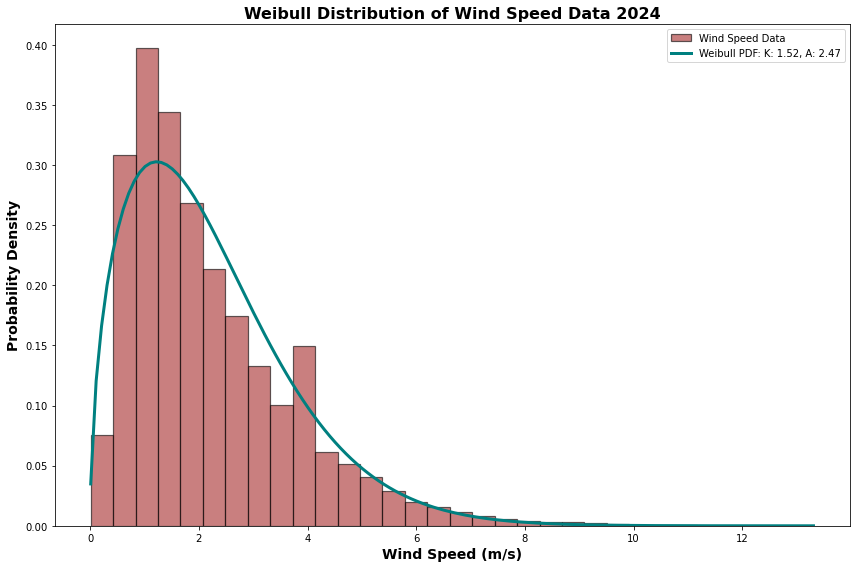

In [ ]:
# computing the weibull distribution parameters for the wind speed data
wind_speed_data = dataset1_2024["wind_speed_mps"].dropna()
min_speed = wind_speed_data.min()
max_speed = wind_speed_data.max()
speed_range = np.arange(min_speed, max_speed + 1, 0.1)
k, loc, scale = weibull_min.fit(wind_speed_data, floc=0)
print(f"K: {k:4.2f}, loc: {loc:.2f}, scale: {scale:.2f}")

# Computing the PDF of the Weibull distribution using the fitted parameters
weibull_pdf = weibull_min.pdf(speed_range, k, loc, scale)

# Plotting the histogram of the wind speed data and the fitted Weibull PDF
plt.figure(figsize=(12,8))
plt.hist(
    speed_range,
    bins=30, 
    density=True,
    alpha=0.6,
    histtype='bar',
    color="brown",
    edgecolor="black",
    linewidth=1.2,
    rwidth=1.0,
    label="Wind Speed Data"
    )
plt.plot(
    speed_range,
    weibull_pdf,
    color="teal",
    linewidth=3,
    label="Weibull PDF: K: {k:.2f}, A: {scale:.2f}".format(k=k, scale=scale)
    )
plt.xlabel("Wind Speed (m/s)", fontsize=14, fontweight="bold")
plt.ylabel("Probability Density", fontsize=14, fontweight="bold")
plt.title("Weibull Distribution of Wind Speed Data 2024", fontsize=16, fontweight="bold")
plt.legend()
plt.tight_layout()
plt.show()


In [9]:
# Using the fitted Weibull parameters to compute the mean and standard deviation of the wind speed

mean_wind_speed = scale * math.gamma(1 + 1/k)

wind_speed_variance = scale**2 * (
    math.gamma(1 + 2/k) - math.gamma(1 + 1/k)**2
)

wind_speed_standard_deviation = math.sqrt(wind_speed_variance)

print(mean_wind_speed)
print(wind_speed_standard_deviation)

2.227515149187492
1.4929411753267856


### Dataset1 STep 2: Statistical Description: Wind Direction

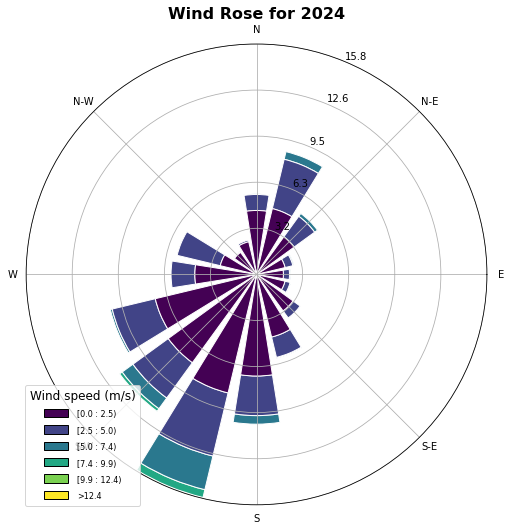

In [10]:
# Plotting windrose diagram for wind direction and speed
wind_direction = dataset1_2024["wind_direction_deg"].dropna()
wind_speed = dataset1_2024["wind_speed_mps"].dropna()

fig = plt.figure(figsize=(8, 8))
ax = WindroseAxes.from_ax(fig=fig)

ax.bar(
    wind_direction,
    wind_speed,
    normed=True,
    opening=0.8,
    edgecolor="white"
)

ax.set_legend(title="Wind speed (m/s)", fontsize=12, title_fontsize=12)
ax.set_title("Wind Rose for 2024",fontsize=16, fontweight="bold")
plt.show()

In [11]:

direction_bins = np.arange(0, 361, 30)

dataset1_2024["direction_sector"] = pd.cut(
    dataset1_2024["wind_direction_deg"],
    bins=direction_bins,
    include_lowest=True,
    right=False
)

direction_frequency = (
    dataset1_2024["direction_sector"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

direction_frequency

direction_sector
[0, 30)       10.805374
[30, 60)       6.991043
[60, 90)       3.269698
[90, 120)      3.081828
[120, 150)     4.922575
[150, 180)     9.662973
[180, 210)    18.460604
[210, 240)    16.375057
[240, 270)    12.027478
[270, 300)     4.833384
[300, 330)     5.353348
[330, 360)     4.216639
Name: proportion, dtype: float64

### Dataset1 Step2 : Statistical Description: Energy Perspective

The goal is to determine whether the directions that occur most frequently are also the directions that contribute most to total wind energy. We compute the directional energy contribution using $u^3$, as wind power is proportional to the cube of the wind speed.

#### 1. Formula

For each direction sector $\theta$, compute:

$$E_{\theta} = 100 \cdot \frac{\sum_{i \in \theta} u_i^3}{\sum_{i} u_i^3}$$

**Where:**

*   **$E_{\theta}$**: Percentage energy contribution from direction sector $\theta$.
*   **$u_i$**: Wind speed at time step $i$.
*   **$u_i^3$**: Wind speed cubed.
*   **$\sum_{i \in \theta} u_i^3$**: Total energy proxy from one specific direction sector.
*   **$\sum_{i} u_i^3$**: Total energy proxy from all directions combined.

---

#### Why $u^3$?

We use the cube of the wind speed because the available wind power is defined as:

$$P = \frac{1}{2} \rho A C_p u^3$$

For a consistent site and turbine, the air density ($\rho$), swept area ($A$), and power coefficient ($C_p$) are treated as constants. Therefore, the directional comparison simplifies to the relationship with **$u^3$**.

In [12]:

# Remove missing wind speed or wind direction values
df_energy = dataset1_2024.dropna(subset=["wind_speed_mps", "wind_direction_deg"]).copy()


# Compute wind-speed cubed
df_energy["wind_speed_cubed"] = df_energy["wind_speed_mps"] ** 3

# Compute directional energy contribution in percentage
directional_energy = (
    df_energy.groupby("direction_sector", observed=False)["wind_speed_cubed"]
    .sum()
    .div(df_energy["wind_speed_cubed"].sum())
    .mul(100)
)

# Combine both results into one table
frequency_vs_energy = pd.DataFrame({
    "directional_frequency_percent": direction_frequency,
    "directional_energy_percent": directional_energy
})

frequency_vs_energy

,directional_frequency_percent,directional_energy_percent
direction_sector,,
"[0, 30)",10.805374,9.212542
"[30, 60)",6.991043,6.012007
"[60, 90)",3.269698,1.828490
"[90, 120)",3.081828,1.210476
"[120, 150)",4.922575,1.645748
"[150, 180)",9.662973,6.006939
"[180, 210)",18.460604,33.801068
"[210, 240)",16.375057,26.134416
"[240, 270)",12.027478,5.798742


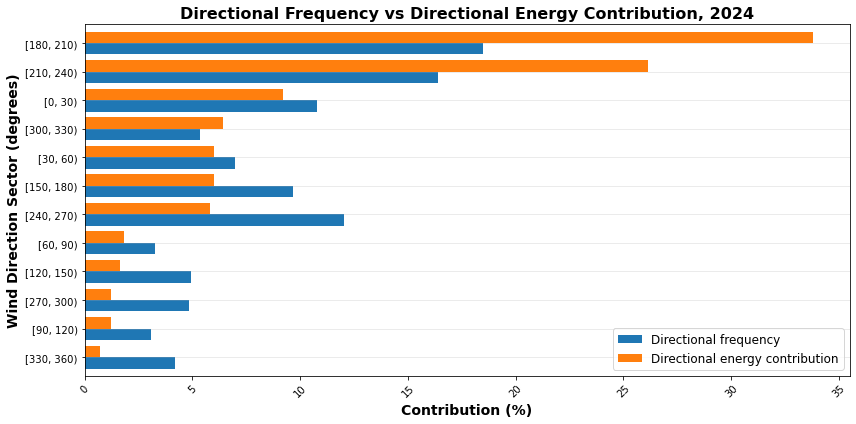

In [13]:
frequency_vs_energy = frequency_vs_energy.sort_values(
    by="directional_energy_percent",
    ascending=True
)

frequency_vs_energy.plot(
    kind="barh",
    figsize=(12, 6),
    width=0.8
)

plt.title("Directional Frequency vs Directional Energy Contribution, 2024", fontsize=16, fontweight="bold")
plt.ylabel("Wind Direction Sector (degrees)", fontsize=14, fontweight="bold")
plt.xlabel("Contribution (%)", fontsize=14, fontweight="bold")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.legend(["Directional frequency", "Directional energy contribution"], fontsize=12)
plt.tight_layout()
plt.show()

### Dataset1 Step 3: Detrending (Scale Separation)

In [14]:
# first, we select the first 3 months of data for 2024
dataset1_2024_q1 = dataset1.loc['2024-01':'2024-03'].dropna().copy()
dataset1_2024_q1.tail()

,wind_speed_mps,wind_direction_deg,temperature_degC
datetime,,,
2024-03-31 23:10:00,0.19,254.40,12.18
2024-03-31 23:20:00,0.22,4.72,11.93
2024-03-31 23:30:00,0.90,185.20,11.67
2024-03-31 23:40:00,1.01,218.20,11.58
2024-03-31 23:50:00,0.46,210.70,11.37


In [15]:
# Employing additive seasonal decomposition to analyze the wind speed time series for the first quarter of 2024
decomposed = seasonal_decompose(dataset1_2024_q1["wind_speed_mps"], model="additive", period=144)

# retrieving the trend, seasonal, and residual components
trend = decomposed.trend
seasonal = decomposed.seasonal
residual = decomposed.resid
# computing the a 24-hour rolling standard deviation of the across components
trend_std = trend.rolling(window=144, center=True).std()
seasonal_std = seasonal.rolling(window=144, center=True).std()
residual_std = residual.rolling(window=144, center=True).std()

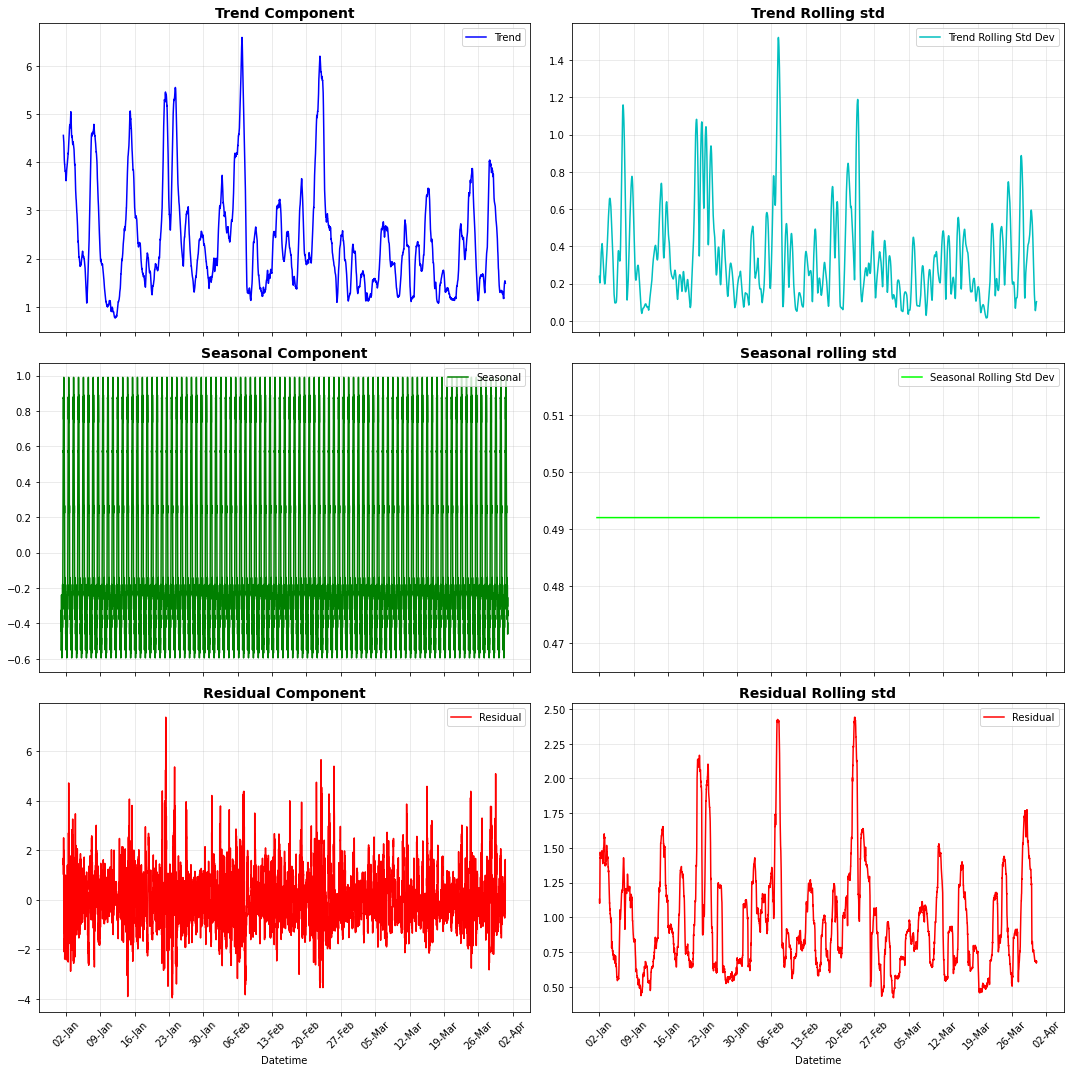

In [16]:
fig, ax = plt.subplots(3,2, figsize=(15, 15), sharex=True)
ax[0, 0].plot(trend, label="Trend", color="blue")
ax[0, 1].plot(trend_std, label="Trend Rolling Std Dev", color='c')
ax[0, 0].set_title("Trend Component", fontsize=14, fontweight="bold")
ax[0, 1].set_title("Trend Rolling std", fontsize=14, fontweight="bold")
ax[1, 0].plot(seasonal, label="Seasonal", color="green")
ax[1, 1].plot(seasonal_std, label="Seasonal Rolling Std Dev", color="lime")
ax[1, 0].set_title("Seasonal Component", fontsize=14, fontweight="bold")
ax[1, 1].set_title("Seasonal rolling std", fontsize=14, fontweight="bold")
ax[2, 0].plot(residual, label="Residual", color="red")
ax[2, 1].plot(residual_std, label="Residual", color="red")
ax[2, 0].set_title("Residual Component", fontsize=14, fontweight="bold")  
ax[2, 1].set_title("Residual Rolling std", fontsize=14, fontweight="bold")

# Hide x-tick labels for the first two rows only
for row in range(2):
    for col in range(2):
        ax[row, col].tick_params(axis="x", labelbottom=False)

# Keep y-ticks visible for all subplots
for axs in ax.flat:
    axs.tick_params(axis="y", labelleft=True)
    axs.grid(True, alpha=0.3)
    axs.legend()

# Format x-axis only on bottom row
locator = mdates.WeekdayLocator(interval=1)
formatter = mdates.DateFormatter("%d-%b")

for axs in ax[2, :]:
    axs.xaxis.set_major_locator(locator)
    axs.xaxis.set_major_formatter(formatter)
    axs.tick_params(axis="x", rotation=45)
    axs.set_xlabel("Datetime")

plt.tight_layout()
plt.show()

In [17]:
trend = dataset1_2024_q1["wind_speed_mps"].rolling(window=144, center=True, min_periods=144).mean()
detrended = dataset1_2024_q1["wind_speed_mps"] - trend
time_of_day = dataset1_2024_q1.index.hour + dataset1_2024_q1.index.minute // 10
seasonal_pattern = detrended.groupby(time_of_day).mean()

seasonal = pd.Series(
    data=time_of_day.map(seasonal_pattern),
    index=dataset1_2024_q1.index
)
seasonal_std = detrended.groupby(time_of_day).std()

residual = dataset1_2024_q1["wind_speed_mps"] - trend - seasonal

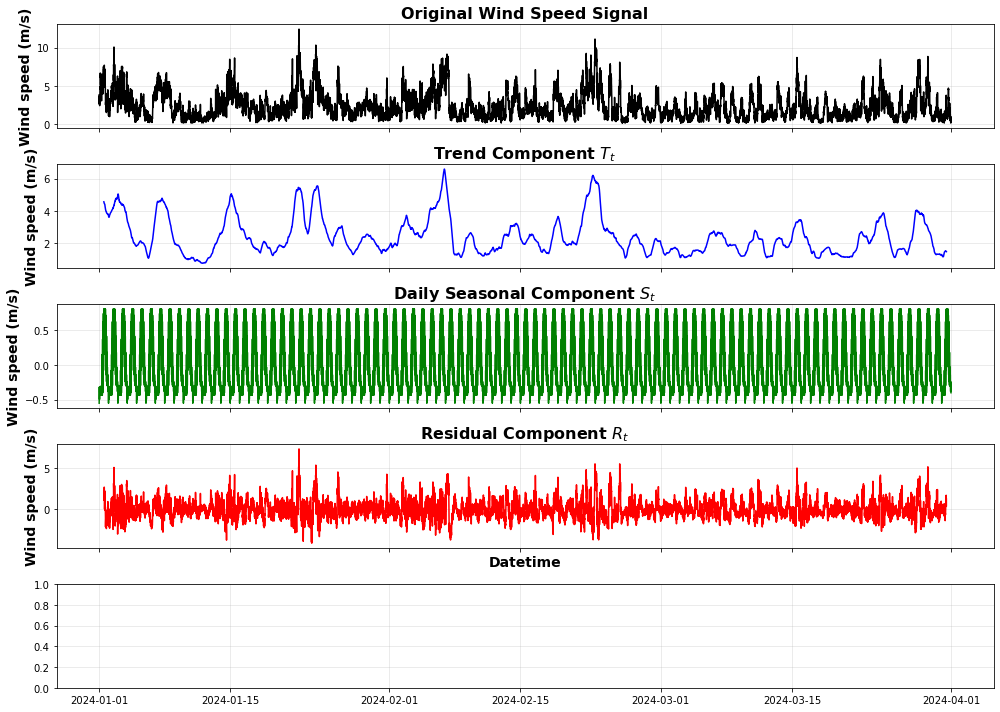

In [24]:
fig, ax = plt.subplots(5, 1, figsize=(14, 10), sharex=True)

ax[0].plot(dataset1_2024_q1["wind_speed_mps"], color="black")
ax[0].set_title("Original Wind Speed Signal", fontsize=16, fontweight="bold")
ax[0].set_ylabel("Wind speed (m/s)", fontsize=14, fontweight="bold")

ax[1].plot(trend, color="blue")
ax[1].set_title("Trend Component $T_t$", fontsize=16, fontweight="bold")
ax[1].set_ylabel("Wind speed (m/s)", fontsize=14, fontweight="bold")

ax[2].plot(seasonal, color="green")
ax[2].set_title("Daily Seasonal Component $S_t$", fontsize=16, fontweight="bold")
ax[2].set_ylabel("Wind speed (m/s)", fontsize=14, fontweight="bold")

ax[3].plot(residual, color="red")
ax[3].set_title("Residual Component $R_t$", fontsize=16, fontweight="bold")
ax[3].set_ylabel("Wind speed (m/s)", fontsize=14, fontweight="bold")
ax[3].set_xlabel("Datetime", fontsize=14, fontweight="bold")


for axs in ax:
    axs.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [19]:

trend_std = trend.rolling(
    window=144,
    center=True,
    min_periods=144
).std()

seasonal_std = seasonal.rolling(
    window=144,
    center=True,
    min_periods=144
).std()

residual_std = residual.rolling(
    window=144,
    center=True,
    min_periods=144
).std()

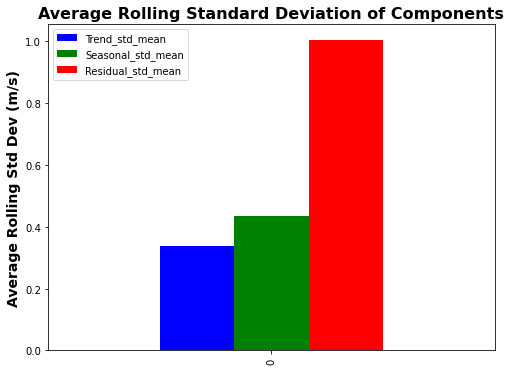

In [20]:
component_variability = pd.DataFrame({
    "Trend_std_mean": [trend_std.mean()],
    "Seasonal_std_mean": [seasonal_std.mean()],
    "Residual_std_mean": [residual_std.mean()]
})

component_variability.plot(
    kind="bar",
    figsize=(8, 6),
    color=["blue", "green", "red"],
    legend=True
)
plt.title("Average Rolling Standard Deviation of Components", fontsize=16, fontweight="bold")
plt.ylabel("Average Rolling Std Dev (m/s)", fontsize=14, fontweight="bold")
plt.show()

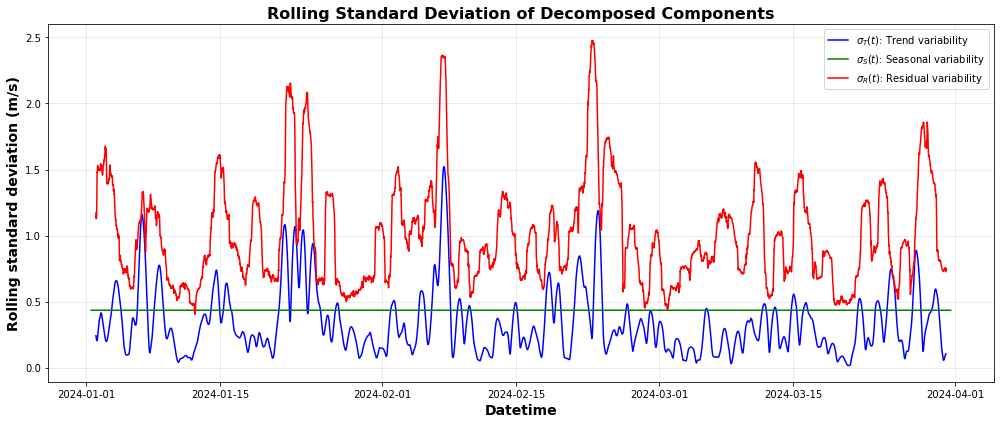

In [25]:
plt.figure(figsize=(14, 6))

plt.plot(trend_std, label=r"$\sigma_T(t)$: Trend variability", color="blue")
plt.plot(seasonal_std, label=r"$\sigma_S(t)$: Seasonal variability", color="green")
plt.plot(residual_std, label=r"$\sigma_R(t)$: Residual variability", color="red")

plt.title("Rolling Standard Deviation of Decomposed Components", fontsize=16, fontweight="bold")
plt.xlabel("Datetime", fontsize=14, fontweight="bold")
plt.ylabel("Rolling standard deviation (m/s)", fontsize=14, fontweight="bold")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### **Emanuele Merveille Guehi - Topic 2**
### **Dataset 2 step 7**

===============================================================================================
                                ### STEP 7: MICROSCALE VARIABILITY
================================================================================================
In this step, we look at a short 10-minute period of the high-frequency 20 Hz wind data. The goal is to see
how the wind speed changes quickly around its local average value.

Raw wind speed:              u(t)

30-second moving average:    u_bar(t)

Fluctuation:                 u'(t) = u(t) - u_bar(t)

========================================================================================================

In [3]:
# ------------------------------------------------------------
# 2. Load data
# ------------------------------------------------------------
# The CSV file is inside the folder called "data".
# Because the notebook is in the main project folder, we use:
# Path("data") / "filename.csv"

csv_path = Path("data") / "one_day_hamburg_multiheight_20hz.csv"

df = pd.read_csv(csv_path, parse_dates=["datetime"])
df = df.set_index("datetime")
# Show first rows to confirm the data loaded correctly
df.head()

,wind_speed_50m_mps,wind_direction_50m_deg,wind_speed_110m_mps,wind_direction_110m_deg,wind_speed_175m_mps,wind_direction_175m_deg,wind_speed_250m_mps,wind_direction_250m_deg
datetime,,,,,,,,
2023-02-01 00:00:00.000,10.05,263.5,18.10,272.6,13.86,271.5,15.38,278.9
2023-02-01 00:00:00.050,9.67,260.8,18.18,273.6,13.95,274.2,15.44,279.4
2023-02-01 00:00:00.100,9.35,260.6,18.44,273.0,13.78,275.7,15.46,278.9
2023-02-01 00:00:00.150,9.42,258.3,18.32,273.5,13.75,275.1,15.68,277.6
2023-02-01 00:00:00.200,9.35,254.6,18.13,272.4,13.67,274.4,15.53,277.4


In [4]:
# ------------------------------------------------------------
# 3. 7 (a) Select a 10 minute period
# ------------------------------------------------------------
# We choose 110 m because it is close to a typical wind turbine hub height.
# This makes the result useful for wind turbine inflow and loading.
#
# We choose 20:35 to 20:45 because it gives a 10-minute period.
# This is consistent with the 10-minute averaging scale commonly used
# in wind energy measurements.
#
# The period also includes the strong fluctuation around 20:40.

height = 110
u_col = f"wind_speed_{height}m_mps"

start_time = "2023-02-01 20:35:00"
end_time = "2023-02-01 20:45:00"

segment = df.loc[start_time:end_time, [u_col]].dropna().copy()

print("\nSelected height:", height, "m")
print("Selected period:", start_time, "to", end_time)
print("Number of samples in selected period:", len(segment))


Selected height: 110 m
Selected period: 2023-02-01 20:35:00 to 2023-02-01 20:45:00
Number of samples in selected period: 11937


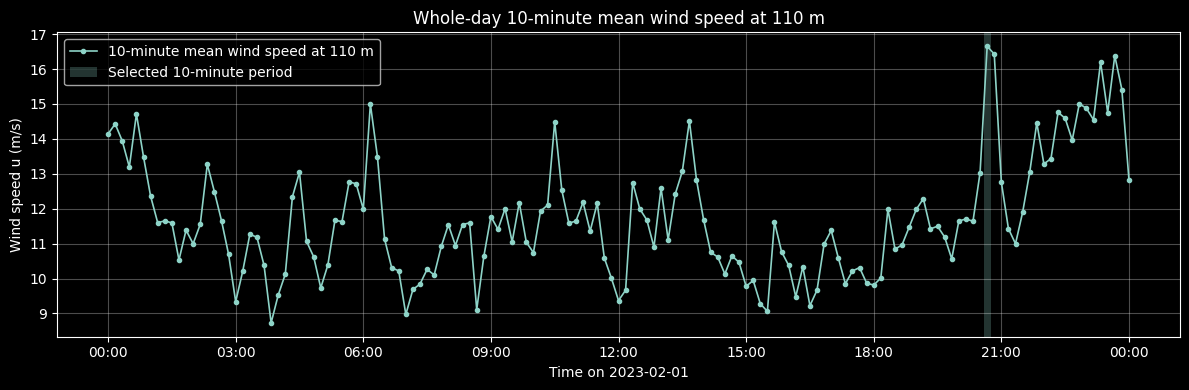

In [7]:
# ------------------------------------------------------------
# 4. Context plot: whole-day 10-minute mean wind speed
# ------------------------------------------------------------
# This plot is NOT the main answer to Step 7(b).
# It only shows where the selected 10-minute period is located
# within the full day.
#
# The original data is 20 Hz, meaning 20 measurements every second.
# If we plot the whole day directly, the graph becomes too crowded.
#
# Therefore, for this context plot ONLY, we use a 10-minute average.
# This is consistent with the standard 10-minute averaging scale
# commonly used in wind energy measurements.
#
# The actual Step 7(b) plot of u(t) is done later in Section 8,
# where we plot the raw 20 Hz wind speed for the selected 10-minute period.

df_10min = df[[u_col]].resample("10min").mean()

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(
    df_10min.index,
    df_10min[u_col],
    marker="o",
    linewidth=1.2,
    markersize=3,
    label=f"10-minute mean wind speed at {height} m"
)

# Highlight the 10-minute period selected for Step 7
ax.axvspan(
    pd.to_datetime(start_time),
    pd.to_datetime(end_time),
    alpha=0.25,
    label="Selected 10-minute period"
)

ax.set_title(f"Whole-day 10-minute mean wind speed at {height} m")
ax.set_ylabel("Wind speed u (m/s)")
ax.set_xlabel("Time on 2023-02-01")
ax.legend()
ax.grid(True, alpha=0.3)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

plt.tight_layout()
plt.show()


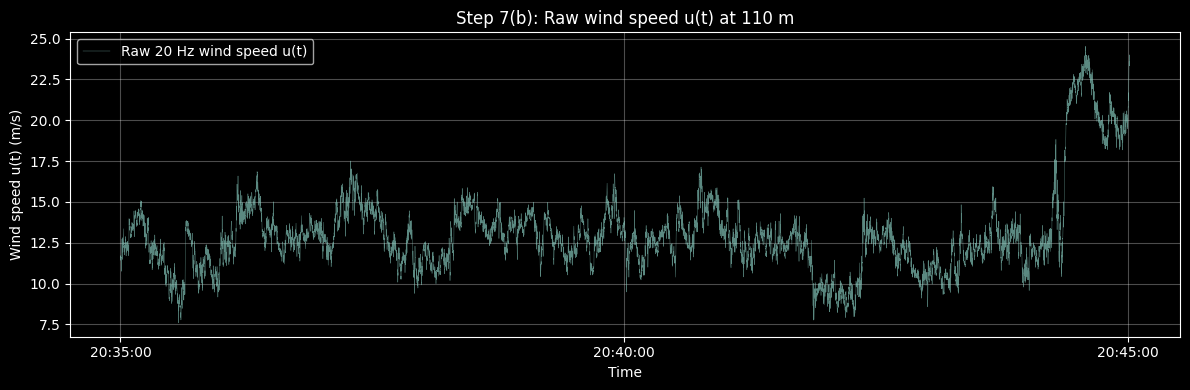

In [8]:
# ============================================================
# 7(b) Plot u(t)
# ============================================================
# Here we plot the raw 20 Hz wind speed for the selected 10-minute period.
#
# we choose thin and slightly transparent because 20 Hz data contains
# many points, so a thick line would make the plot hard to read.

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(
    segment.index,
    segment[u_col],
    linewidth=0.3,
    alpha=0.65,
    label="Raw 20 Hz wind speed u(t)"
)

ax.set_title(f"Step 7(b): Raw wind speed u(t) at {height} m")
ax.set_ylabel("Wind speed u(t) (m/s)")
ax.set_xlabel("Time")
ax.legend()
ax.grid(True, alpha=0.3)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))

plt.tight_layout()
plt.show()

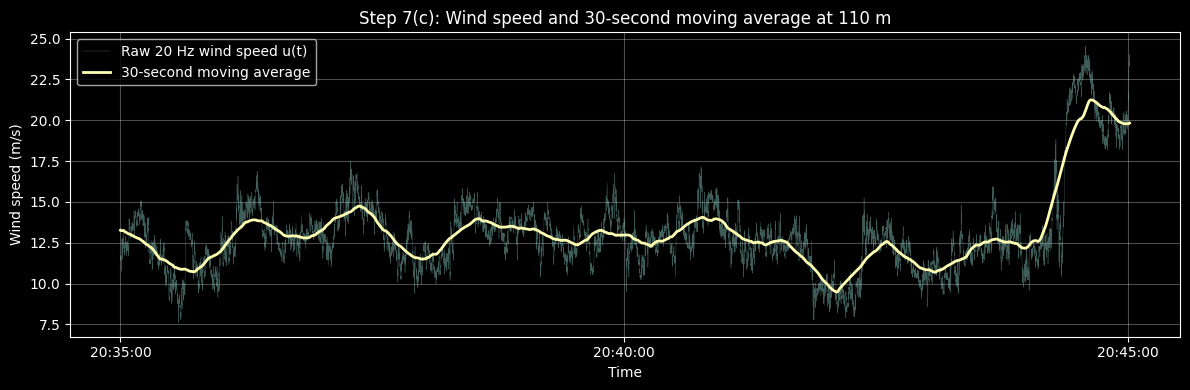

In [9]:
# ============================================================
# 7(c) Compute and plot short-time moving average
# ============================================================
# The moving average represents the local/background wind speed.
#
# The exercise suggests a short-time moving average of about 10–30 seconds.
# We use 30 seconds because it smooths the very fast fluctuations,
# but it still follows the short-term change of the wind.

moving_average_window = "30s"

segment["u_bar_30s"] = segment[u_col].rolling(
    moving_average_window,
    center=True,
    min_periods=1
).mean()

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(
    segment.index,
    segment[u_col],
    linewidth=0.3,
    alpha=0.45,
    label="Raw 20 Hz wind speed u(t)"
)

ax.plot(
    segment.index,
    segment["u_bar_30s"],
    linewidth=2.0,
    label="30-second moving average"
)

ax.set_title(f"Step 7(c): Wind speed and 30-second moving average at {height} m")
ax.set_ylabel("Wind speed (m/s)")
ax.set_xlabel("Time")
ax.legend()
ax.grid(True, alpha=0.3)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))

plt.tight_layout()
plt.show()

In [10]:
# ============================================================
# 7(d) Compute fluctuations u'(t)
# ============================================================
# The fluctuation is the difference between the real measured wind speed
# and the 30-second moving average.
#
# Formula:
# u'(t) = u(t) - u_bar(t)
#
# If u'(t) is positive, the wind speed is above the local average.
# If u'(t) is negative, the wind speed is below the local average.

segment["u_prime"] = segment[u_col] - segment["u_bar_30s"]

print("\nSTEP 7(d): FLUCTUATION COMPUTED")
print("-------------------------------")
print("New column added: u_prime")
print(segment[[u_col, "u_bar_30s", "u_prime"]].head())


STEP 7(d): FLUCTUATION COMPUTED
-------------------------------
New column added: u_prime
                         wind_speed_110m_mps  u_bar_30s   u_prime
datetime                                                         
2023-02-01 20:35:00.000                11.71  13.263300 -1.553300
2023-02-01 20:35:00.050                11.42  13.259635 -1.839635
2023-02-01 20:35:00.100                11.53  13.256954 -1.726954
2023-02-01 20:35:00.150                11.69  13.253894 -1.563894
2023-02-01 20:35:00.200                11.70  13.252270 -1.552270


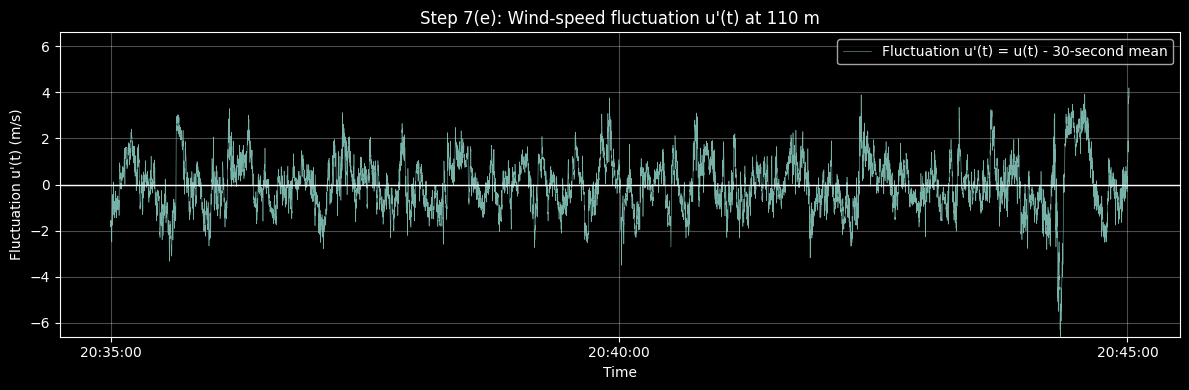

In [11]:
# ============================================================
# 7(e) Plot u'(t)
# ============================================================
# This plot shows the fast-changing part of the wind.
# These fluctuations are linked to turbulence and gust-like variations.

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(
    segment.index,
    segment["u_prime"],
    linewidth=0.4,
    alpha=0.85,
    label="Fluctuation u'(t) = u(t) - 30-second mean"
)

ax.axhline(0, linewidth=1)

# Make positive and negative fluctuation scale balanced
limit = max(abs(segment["u_prime"].min()), abs(segment["u_prime"].max()))
ax.set_ylim(-limit, limit)

ax.set_title(f"Step 7(e): Wind-speed fluctuation u'(t) at {height} m")
ax.set_ylabel("Fluctuation u'(t) (m/s)")
ax.set_xlabel("Time")
ax.legend()
ax.grid(True, alpha=0.3)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))

plt.tight_layout()
plt.show()

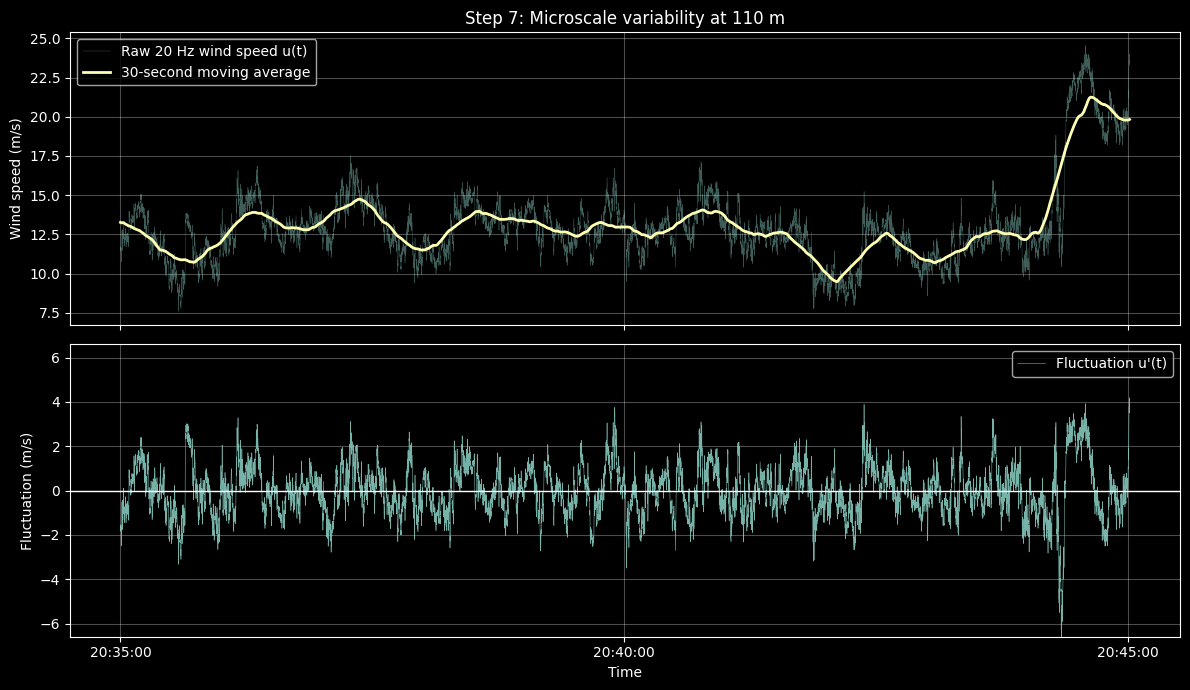


Saved report-ready figure to: figures\step7_microscale_variability_110m_10min.png


In [12]:
# ============================================================
# Report-ready Step 7 figure
# ============================================================
# This figure combines the most important Step 7 results:
# Top: raw wind speed and 30-second moving average
# Bottom: fluctuation u'(t)
#
# This is the figure that can be used in the final short report.

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# Top panel: raw wind speed and moving average
axes[0].plot(
    segment.index,
    segment[u_col],
    linewidth=0.3,
    alpha=0.45,
    label="Raw 20 Hz wind speed u(t)"
)

axes[0].plot(
    segment.index,
    segment["u_bar_30s"],
    linewidth=2.0,
    label="30-second moving average"
)

axes[0].set_title(f"Step 7: Microscale variability at {height} m")
axes[0].set_ylabel("Wind speed (m/s)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Bottom panel: fluctuation
axes[1].plot(
    segment.index,
    segment["u_prime"],
    linewidth=0.4,
    alpha=0.85,
    label="Fluctuation u'(t)"
)

axes[1].axhline(0, linewidth=1)
axes[1].set_ylim(-limit, limit)

axes[1].set_ylabel("Fluctuation (m/s)")
axes[1].set_xlabel("Time")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))

plt.tight_layout()

# Save the figure
figures_path = Path("figures")
figures_path.mkdir(exist_ok=True)

output_path = figures_path / "step7_microscale_variability_110m_10min.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight")

plt.show()

print("\nSaved report-ready figure to:", output_path)


In [13]:
# ============================================================
# 7(f) Interpretation and statistics
# ============================================================
# These values summarize the selected 10-minute period.
# They help us write the report interpretation.

mean_u = segment[u_col].mean()
std_u = segment[u_col].std()
min_u = segment[u_col].min()
max_u = segment[u_col].max()
std_u_prime = segment["u_prime"].std()

print("\nSTEP 7(f): STATISTICS")
print("---------------------")
print(f"Height: {height} m")
print(f"Selected period: {start_time} to {end_time}")
print(f"Mean wind speed: {mean_u:.2f} m/s")
print(f"Standard deviation of wind speed: {std_u:.2f} m/s")
print(f"Minimum wind speed: {min_u:.2f} m/s")
print(f"Maximum wind speed: {max_u:.2f} m/s")
print(f"Standard deviation of fluctuation u': {std_u_prime:.2f} m/s")

print("\nSHORT INTERPRETATION")
print("--------------------")
print(
    "The selected 10-minute period shows that the wind speed is not steady. "
    "The raw 20 Hz signal fluctuates rapidly around the 30-second moving average. "
    "The moving average represents the local background wind speed, while u'(t) "
    "represents the fast turbulent fluctuation. These small-scale fluctuations are "
    "important for wind turbines because they can cause power variations, unsteady "
    "blade loading, vibration, and long-term fatigue."
)


STEP 7(f): STATISTICS
---------------------
Height: 110 m
Selected period: 2023-02-01 20:35:00 to 2023-02-01 20:45:00
Mean wind speed: 13.09 m/s
Standard deviation of wind speed: 2.60 m/s
Minimum wind speed: 7.59 m/s
Maximum wind speed: 24.54 m/s
Standard deviation of fluctuation u': 1.14 m/s

SHORT INTERPRETATION
--------------------
The selected 10-minute period shows that the wind speed is not steady. The raw 20 Hz signal fluctuates rapidly around the 30-second moving average. The moving average represents the local background wind speed, while u'(t) represents the fast turbulent fluctuation. These small-scale fluctuations are important for wind turbines because they can cause power variations, unsteady blade loading, vibration, and long-term fatigue.


### **Step 8**

In [ ]:
# ============================================================
# STEP 8: TURBULENCE INTENSITY
# ============================================================
# Exercise goal:
# a) Compute turbulence intensity TI in 10-minute windows for all heights
#    and plot the result.
# b) For one selected height, plot mean wind speed u(t), standard deviation
#    sigma_u(t), and turbulence intensity TI(t).
# c) Identify:
#    - strong steady flow
#    - weak but turbulent flow
#
# Formula:
# TI = sigma_u / mean_u
#
# where:
# mean_u  = mean wind speed in each 10-minute window
# sigma_u = standard deviation of wind speed in each 10-minute window
# TI      = turbulence intensity
# ============================================================


Wind-speed columns found:
50 m: wind_speed_50m_mps
110 m: wind_speed_110m_mps
175 m: wind_speed_175m_mps
250 m: wind_speed_250m_mps

STEP 8(a): TURBULENCE INTENSITY SUMMARY
---------------------------------------


,height_m,mean_wind_speed_mps,mean_sigma_u_mps,mean_TI_percent,max_TI_percent
0,50,9.438603,1.903693,20.143902,30.395485
1,110,11.710796,1.721205,14.664997,25.876849
2,175,13.629284,1.686783,12.398880,20.466744
3,250,15.820771,1.681810,10.666291,16.924828


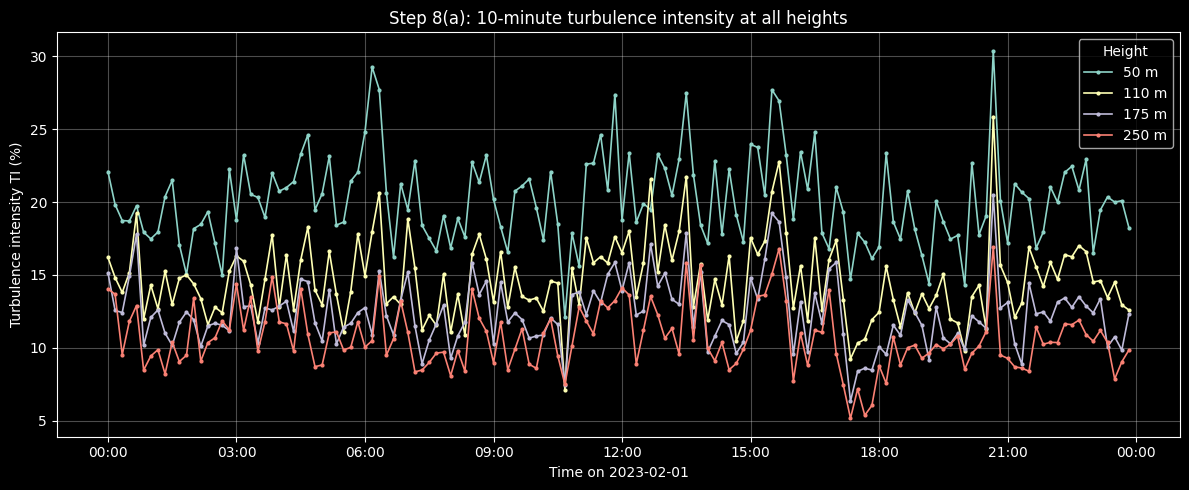

In [23]:
# ============================================================
# 8(a) Compute TI in 10-minute windows for all heights
# ============================================================

# For each 10-minute window and each height, we compute:
# mean_u  = average wind speed
# sigma_u = standard deviation of wind speed
# TI      = sigma_u / mean_u
#
# We multiply TI by 100 when plotting, so the y-axis is in percent.

# Found all wind speed columns, for example:
# wind_speed_50m_mps, wind_speed_110m_mps, etc.
speed_cols = [
    col for col in df.columns
    if col.startswith("wind_speed_") and col.endswith("m_mps")
]

# Sort columns by height, so plots go from lowest to highest height
def extract_height(col_name):
    match = re.search(r"wind_speed_(\d+)m_mps", col_name)
    return int(match.group(1)) if match else None

speed_cols = sorted(speed_cols, key=extract_height)
heights = [extract_height(col) for col in speed_cols]

print("Wind-speed columns found:")
for h, col in zip(heights, speed_cols):
    print(f"{h} m: {col}")


# Use 10-minute windows
window = "10min"

# 10-minute mean wind speed
mean_u_10min = df[speed_cols].resample(window).mean()

# 10-minute standard deviation of wind speed
sigma_u_10min = df[speed_cols].resample(window).std()

# Turbulence intensity
ti_10min = sigma_u_10min / mean_u_10min

# Convert TI to percent for easier interpretation
ti_10min_percent = ti_10min * 100


# Print summary values for all heights
summary_rows = []

for h, col in zip(heights, speed_cols):
    summary_rows.append({
        "height_m": h,
        "mean_wind_speed_mps": mean_u_10min[col].mean(),
        "mean_sigma_u_mps": sigma_u_10min[col].mean(),
        "mean_TI_percent": ti_10min_percent[col].mean(),
        "max_TI_percent": ti_10min_percent[col].max()
    })

ti_summary = pd.DataFrame(summary_rows)

print("\nSTEP 8(a): TURBULENCE INTENSITY SUMMARY")
print("---------------------------------------")
display(ti_summary)


# Plot TI for all heights
fig, ax = plt.subplots(figsize=(12, 5))

for h, col in zip(heights, speed_cols):
    ax.plot(
        ti_10min_percent.index,
        ti_10min_percent[col],
        linewidth=1.2,
        marker="o",
        markersize=2,
        label=f"{h} m"
    )

ax.set_title("Step 8(a): 10-minute turbulence intensity at all heights")
ax.set_ylabel("Turbulence intensity TI (%)")
ax.set_xlabel("Time on 2023-02-01")
ax.legend(title="Height")
ax.grid(True, alpha=0.3)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

plt.tight_layout()
plt.show()

# From the plot the noticeable trends are
# 50 m has the highest TI most of the day, often around 17–25%, with peaks close to 30%.
# 110 m is usually lower than 50 m, but still sometimes quite turbulent.
# 175 m is mostly lower than 50 m and 110 m.
# 250 m usually has the lowest TI, often around 8–13%.

# 50 m = most turbulent
# 110 m = still turbulent
# 175 m = moderate
# 250 m = usually least turbulent

# **Why does this happen?**

# Near the ground, the wind is affected by:

 # surface roughness + friction + buildings/trees/terrain + wind shear

# These effects disturb the flow and create more fluctuations. So at 50 m, the wind is more “shaky” compared# with its mean value.

# At higher heights, like 175 m and 250 m, the wind is farther away from the surface, so it is usually # smoother. That is why the TI is generally lower.

#There is also a strong spike around 20:40–21:00 at several heights. That likely represents a short turbulent # event or gusty flow affecting the whole vertical profile.

In [24]:
# ============================================================
# 8(a) Interpretation: trends with height
# ============================================================
# The plot above shows how turbulence intensity changes with height.
#
# Main trend:
# TI is generally highest at the lowest height, 50 m,
# and generally lowest at the highest height, 250 m.
#
# Physical reason:
# Lower heights are closer to the ground, so the wind is more affected by
# surface roughness, friction, buildings, trees, and terrain.
# These effects disturb the flow and increase wind-speed fluctuations.
#
# Higher heights are farther from the surface, so the flow is usually smoother
# and the turbulence intensity is lower.

print("\nSTEP 8(a): TREND INTERPRETATION")
print("-------------------------------")
print(
    "The turbulence intensity is generally highest at 50 m and lowest at 250 m. "
    "This means that the lower measurement levels experience stronger wind-speed "
    "fluctuations relative to their mean wind speed. The main reason is that lower "
    "heights are more affected by surface roughness, friction, and obstacles, which "
    "generate turbulence. At higher levels, the wind is farther away from the ground "
    "and is usually smoother, so the turbulence intensity is lower. A short spike "
    "around 20:40–21:00 appears at several heights, suggesting a gusty or turbulent "
    "event affecting much of the vertical profile."
)


STEP 8(a): TREND INTERPRETATION
-------------------------------
The turbulence intensity is generally highest at 50 m and lowest at 250 m. This means that the lower measurement levels experience stronger wind-speed fluctuations relative to their mean wind speed. The main reason is that lower heights are more affected by surface roughness, friction, and obstacles, which generate turbulence. At higher levels, the wind is farther away from the ground and is usually smoother, so the turbulence intensity is lower. A short spike around 20:40–21:00 appears at several heights, suggesting a gusty or turbulent event affecting much of the vertical profile.



STEP 8(b): SELECTED HEIGHT
--------------------------
Selected height: 110 m
                        mean_u   sigma_u  TI_percent
datetime                                            
2023-02-01 00:00:00  14.141096  2.291672   16.205762
2023-02-01 00:10:00  14.428730  2.138416   14.820545
2023-02-01 00:20:00  13.941509  1.923681   13.798227
2023-02-01 00:30:00  13.193342  2.001208   15.168319
2023-02-01 00:40:00  14.713598  2.829659   19.231591


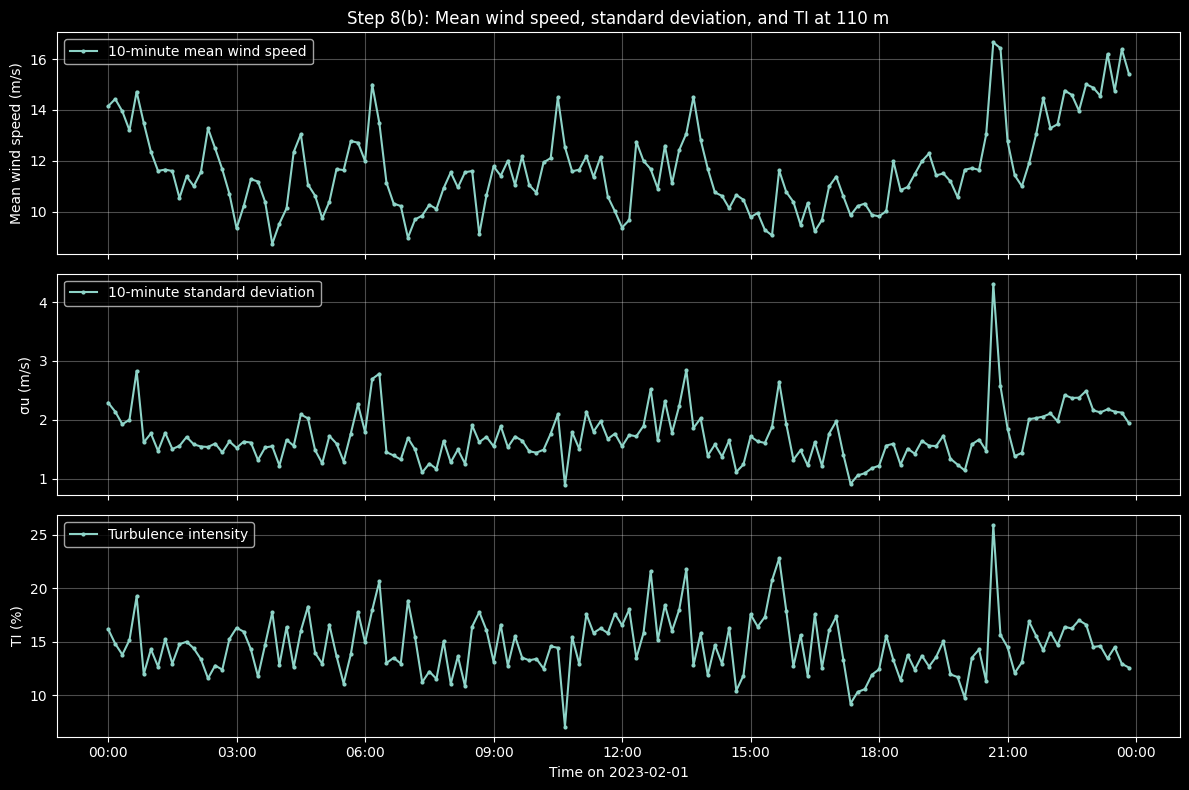

In [17]:
# ============================================================
# 8(b) Plot mean wind speed, sigma_u, and TI for one height
# ============================================================
# We choose 110 m because it is close to a typical wind turbine hub height.
# This makes the result relevant for turbine inflow and loading.
#
# Important:
# Here, u(t) means the 10-minute mean wind speed, not the raw 20 Hz signal.
# This matches the 10-minute-window calculation of turbulence intensity.

selected_height = 110
selected_col = f"wind_speed_{selected_height}m_mps"

selected_metrics = pd.DataFrame({
    "mean_u": mean_u_10min[selected_col],
    "sigma_u": sigma_u_10min[selected_col],
    "TI_percent": ti_10min_percent[selected_col]
}).dropna()

print("\nSTEP 8(b): SELECTED HEIGHT")
print("--------------------------")
print("Selected height:", selected_height, "m")
print(selected_metrics.head())


# Plot mean wind speed, standard deviation, and TI for selected height
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

# Top panel: 10-minute mean wind speed
axes[0].plot(
    selected_metrics.index,
    selected_metrics["mean_u"],
    linewidth=1.5,
    marker="o",
    markersize=2,
    label="10-minute mean wind speed"
)

axes[0].set_title(f"Step 8(b): Mean wind speed, standard deviation, and TI at {selected_height} m")
axes[0].set_ylabel("Mean wind speed (m/s)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)


# Middle panel: 10-minute standard deviation
axes[1].plot(
    selected_metrics.index,
    selected_metrics["sigma_u"],
    linewidth=1.5,
    marker="o",
    markersize=2,
    label="10-minute standard deviation"
)

axes[1].set_ylabel("σu (m/s)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)


# Bottom panel: turbulence intensity
axes[2].plot(
    selected_metrics.index,
    selected_metrics["TI_percent"],
    linewidth=1.5,
    marker="o",
    markersize=2,
    label="Turbulence intensity"
)

axes[2].set_ylabel("TI (%)")
axes[2].set_xlabel("Time on 2023-02-01")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

plt.tight_layout()
plt.show()

In [18]:
# ============================================================
# 8(c) Identify strong steady flow and weak but turbulent flow
# ============================================================
# Strong steady flow:
# - high mean wind speed
# - low turbulence intensity
#
# Weak but turbulent flow:
# - low mean wind speed
# - high turbulence intensity
#
# To avoid choosing arbitrary numbers, we use the data itself:
# high wind speed = above the 75th percentile
# low wind speed  = below the 25th percentile
# high TI         = above the 75th percentile
# low TI          = below the 25th percentile

u_high = selected_metrics["mean_u"].quantile(0.75)
u_low = selected_metrics["mean_u"].quantile(0.25)

ti_high = selected_metrics["TI_percent"].quantile(0.75)
ti_low = selected_metrics["TI_percent"].quantile(0.25)

print("\nSTEP 8(c): THRESHOLDS")
print("---------------------")
print(f"High wind-speed threshold, 75th percentile: {u_high:.2f} m/s")
print(f"Low wind-speed threshold, 25th percentile: {u_low:.2f} m/s")
print(f"High TI threshold, 75th percentile: {ti_high:.2f} %")
print(f"Low TI threshold, 25th percentile: {ti_low:.2f} %")


# Classify periods
strong_steady = selected_metrics[
    (selected_metrics["mean_u"] >= u_high) &
    (selected_metrics["TI_percent"] <= ti_low)
].copy()

weak_turbulent = selected_metrics[
    (selected_metrics["mean_u"] <= u_low) &
    (selected_metrics["TI_percent"] >= ti_high)
].copy()


print("\nStrong steady flow periods:")
print("---------------------------")
if len(strong_steady) > 0:
    display(strong_steady)
else:
    print("No period satisfies both conditions exactly.")


print("\nWeak but turbulent flow periods:")
print("--------------------------------")
if len(weak_turbulent) > 0:
    display(weak_turbulent)
else:
    print("No period satisfies both conditions exactly.")



STEP 8(c): THRESHOLDS
---------------------
High wind-speed threshold, 75th percentile: 12.55 m/s
Low wind-speed threshold, 25th percentile: 10.51 m/s
High TI threshold, 75th percentile: 16.25 %
Low TI threshold, 25th percentile: 12.80 %

Strong steady flow periods:
---------------------------


,mean_u,sigma_u,TI_percent
datetime,,,
2023-02-01 00:50:00,13.484781,1.615690,11.981581
2023-02-01 02:20:00,13.272558,1.537901,11.587075
2023-02-01 20:30:00,13.034048,1.475783,11.322520
2023-02-01 23:50:00,15.410222,1.940459,12.592023



Weak but turbulent flow periods:
--------------------------------


,mean_u,sigma_u,TI_percent
datetime,,,
2023-02-01 03:00:00,9.337522,1.522963,16.310142
2023-02-01 03:50:00,8.728717,1.550063,17.758201
2023-02-01 04:10:00,10.126468,1.659025,16.383055
2023-02-01 05:10:00,10.386265,1.725574,16.614004
2023-02-01 07:00:00,8.972108,1.690627,18.843136
2023-02-01 08:40:00,9.108127,1.619404,17.779767
2023-02-01 11:50:00,10.007532,1.764101,17.627736
2023-02-01 12:00:00,9.367756,1.548996,16.535397
2023-02-01 12:10:00,9.664743,1.741359,18.017641


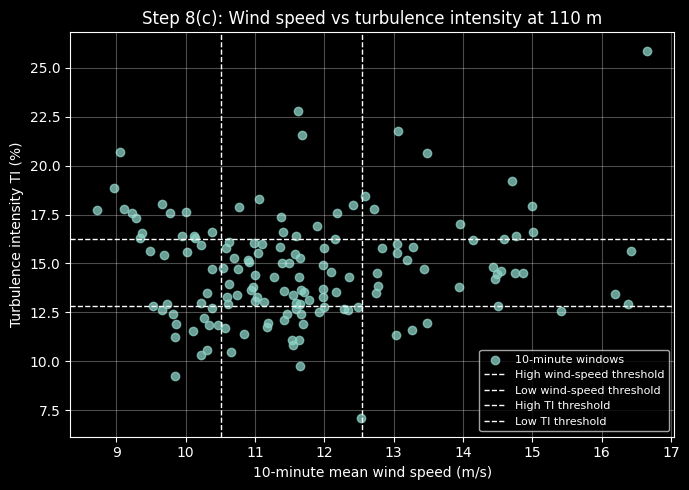

In [19]:
# ------------------------------------------------------------
# Additional helpful plot for 8(c)
# ------------------------------------------------------------
# This scatter plot helps us see the relationship between mean wind speed
# and turbulence intensity.
#
# Points on the right and low down = strong and steady.
# Points on the left and high up = weak but turbulent.

fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(
    selected_metrics["mean_u"],
    selected_metrics["TI_percent"],
    alpha=0.75,
    label="10-minute windows"
)

# Threshold lines
ax.axvline(u_high, linestyle="--", linewidth=1, label="High wind-speed threshold")
ax.axvline(u_low, linestyle="--", linewidth=1, label="Low wind-speed threshold")
ax.axhline(ti_high, linestyle="--", linewidth=1, label="High TI threshold")
ax.axhline(ti_low, linestyle="--", linewidth=1, label="Low TI threshold")

ax.set_title(f"Step 8(c): Wind speed vs turbulence intensity at {selected_height} m")
ax.set_xlabel("10-minute mean wind speed (m/s)")
ax.set_ylabel("Turbulence intensity TI (%)")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

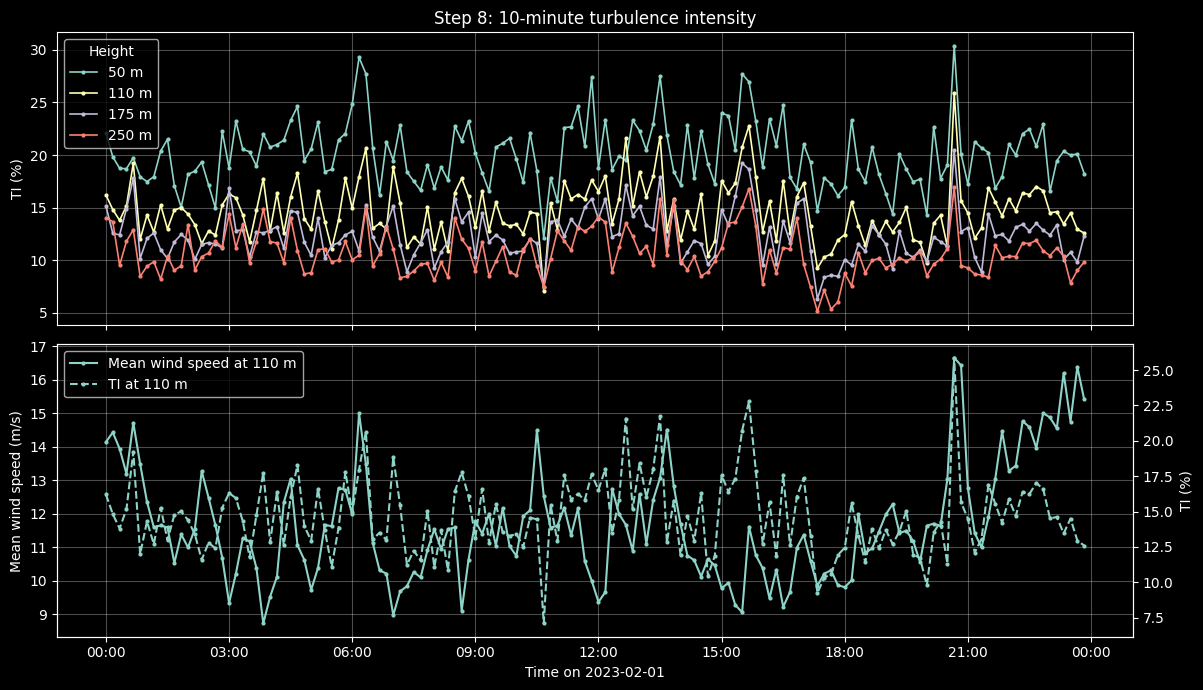


Saved report-ready figure to: figures\step8_turbulence_intensity_10min.png


In [20]:

# ============================================================
# Report-ready Step 8 figure
# ============================================================
# This figure can be used in the final report.
# It shows:
# Top: TI for all heights
# Bottom: mean wind speed and TI for the selected hub-height-like level.
#
# This keeps the report shorter while still answering the main Step 8 points.

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# Top panel: TI at all heights
for h, col in zip(heights, speed_cols):
    axes[0].plot(
        ti_10min_percent.index,
        ti_10min_percent[col],
        linewidth=1.2,
        marker="o",
        markersize=2,
        label=f"{h} m"
    )

axes[0].set_title("Step 8: 10-minute turbulence intensity")
axes[0].set_ylabel("TI (%)")
axes[0].legend(title="Height")
axes[0].grid(True, alpha=0.3)


# Bottom panel: selected height mean wind speed and TI
axes[1].plot(
    selected_metrics.index,
    selected_metrics["mean_u"],
    linewidth=1.5,
    marker="o",
    markersize=2,
    label=f"Mean wind speed at {selected_height} m"
)

axes[1].set_ylabel("Mean wind speed (m/s)")
axes[1].set_xlabel("Time on 2023-02-01")
axes[1].grid(True, alpha=0.3)

# Add TI on a second y-axis
ax2 = axes[1].twinx()

ax2.plot(
    selected_metrics.index,
    selected_metrics["TI_percent"],
    linewidth=1.5,
    marker="o",
    markersize=2,
    linestyle="--",
    label=f"TI at {selected_height} m"
)

ax2.set_ylabel("TI (%)")

# Combine legends from both y-axes
lines_1, labels_1 = axes[1].get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
axes[1].legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left")

axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

plt.tight_layout()

# Save the figure
figures_path = Path("figures")
figures_path.mkdir(exist_ok=True)

output_path = figures_path / "step8_turbulence_intensity_10min.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight")

plt.show()

print("\nSaved report-ready figure to:", output_path)

In [21]:
# ============================================================
# 8(d) Short interpretation for notebook/report
# ============================================================
# This interpretation explains the physical meaning.
#
# High TI means the wind fluctuates strongly compared with its mean value.
# Low TI means the wind is smoother and steadier.
#
# For turbines:
# - strong steady wind is good for power production
# - weak but turbulent wind can still cause mechanical loading/fatigue,
#   even though it may produce less power

print("\nSHORT INTERPRETATION")
print("--------------------")
print(
    "Turbulence intensity was computed from 10-minute windows as TI = sigma_u / mean_u. "
    "The TI plot compares how strongly the wind fluctuates at different measurement heights. "
    "In general, lower heights can show stronger turbulence because they are more affected by "
    "surface roughness and friction, while higher levels may be smoother. However, the exact trend "
    "can change during the day depending on atmospheric stability and flow conditions. "
    "Strong steady flow corresponds to high mean wind speed with low TI, which is favourable for "
    "power production. Weak but turbulent flow corresponds to low mean wind speed with high TI, "
    "which is less useful for energy production but can still contribute to turbine loading and fatigue."
)


SHORT INTERPRETATION
--------------------
Turbulence intensity was computed from 10-minute windows as TI = sigma_u / mean_u. The TI plot compares how strongly the wind fluctuates at different measurement heights. In general, lower heights can show stronger turbulence because they are more affected by surface roughness and friction, while higher levels may be smoother. However, the exact trend can change during the day depending on atmospheric stability and flow conditions. Strong steady flow corresponds to high mean wind speed with low TI, which is favourable for power production. Weak but turbulent flow corresponds to low mean wind speed with high TI, which is less useful for energy production but can still contribute to turbine loading and fatigue.
